# CVaR Portfolio Optimisation

**Paper inspiration:** *Optimization of Conditional Value-at-Risk* — R. T. Rockafellar & S. Uryasev, **Journal of Risk** 2 (2000) 21–41.

## The big idea (explained for a 5-year-old)

Imagine you have a piggy bank, and instead of just putting all your money on **one** toy, you split it across many toys. That bag of toys is a **portfolio**.

Some toys go **up** in value (you can sell them for more) and some go **down** (you'd sell for less). The day-to-day change in price is called a **return**. Returns can be positive (yay!) or negative (ouch).

The problem is: bad days happen. We want to build a portfolio that doesn't hurt too much when those bad days come. That is what **CVaR optimisation** is for — it asks the question:

> *"Out of the worst 5% of days, what is the **average** loss I will face? And how do I split my piggy bank so that average loss is as small as possible?"*

That worst-tail-average is **CVaR** — Conditional Value-at-Risk. This notebook builds a CVaR-optimised portfolio of Indian large-cap stocks, backtests it from 2018–today, and compares it against an equal-weight basket, a minimum-variance basket, and the NIFTY 50 index.

---
## Vocabulary, kid-friendly

| Word | What it means |
|------|---------------|
| **Stock** | A tiny piece of a company. If the company does well its piece is worth more. |
| **Portfolio** | A bag of many stocks. Some bags are safer, some are riskier. |
| **Return** | How much money you made or lost as a percent. +1% means ₹1000 became ₹1010. |
| **Risk** | How bouncy your bag is — how big the ups and downs are day to day. |
| **Volatility** | A number for how bouncy. High volatility = wild ride. Low = chill ride. |
| **Drawdown** | The biggest dip from your highest peak. Like the steepest fall on a roller-coaster. |
| **VaR (Value-at-Risk)** | "On a normal-bad day (worst 5%), what's the *line* I won't cross?" |
| **CVaR (Expected Shortfall)** | "On those worst 5% days, what's the *average* loss?" — kinder to outliers than VaR. |
| **Optimisation** | The computer trying many recipes for the bag and picking the best one. |
| **Rebalancing** | Every month we re-mix the bag because winners and losers shift. |
| **Sharpe ratio** | Bang-per-buck of risk. Higher is better. |

In [1]:
# --- Standard scientific stack --- 
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import linprog, minimize
warnings.filterwarnings('ignore')

# --- Project paths ---
DATA_DIR = '../dataset'  # 450+ Indian stock CSVs
INDEX_FILE = os.path.join(DATA_DIR, 'NIFTY.csv')
OUT_DIR = '.'

# --- Plot defaults ---
plt.rcParams.update({
    'figure.figsize': (11, 5),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# --- Reproducibility ---
np.random.seed(7)
print('Setup OK. Pandas', pd.__version__, '| NumPy', np.__version__)

Setup OK. Pandas 2.3.3 | NumPy 2.3.5


## 1. Picking the playground (the universe)

We need a list of stocks to choose from. Picking *every* stock would slow the computer and add tiny illiquid names that distort risk numbers. Instead we use a fixed list of **40 well-known Indian large-cap companies** — the kind of names you'd see on a giant TV ticker tape. Every project in this folder uses these CSVs from `dataset/`.

**Why large-caps?** Big companies trade a lot, so their prices are clean (no weird gaps). For a *first* CVaR run, clean data > a giant universe.

In [2]:
UNIVERSE_REQUEST = [
    'RELIANCE','TCS','HDFCBANK','INFY','ICICIBANK','HINDUNILVR','ITC','SBIN',
    'BHARTIARTL','KOTAKBANK','LT','AXISBANK','BAJFINANCE','ASIANPAINT','MARUTI',
    'HCLTECH','WIPRO','ONGC','NTPC','TITAN','SUNPHARMA','NESTLEIND','ULTRACEMCO',
    'POWERGRID','M&M','TATASTEEL','BAJAJFINSV','ADANIENT','JSWSTEEL','DRREDDY',
    'GRASIM','CIPLA','INDUSINDBK','COALINDIA','TECHM','HEROMOTOCO','BPCL',
    'DIVISLAB','BRITANNIA','HINDALCO','BAJAJ-AUTO','EICHERMOT','UPL','APOLLOHOSP',
    'TATACONSUM','SBILIFE','HDFCLIFE','ICICIPRULI','ADANIPORTS','TATACOMM',
]
# Keep only tickers whose CSV actually exists -> notebook is robust to dataset drift.
UNIVERSE = [t for t in UNIVERSE_REQUEST if os.path.exists(os.path.join(DATA_DIR, f'{t}.csv'))]
missing = sorted(set(UNIVERSE_REQUEST) - set(UNIVERSE))
if missing:
    print(f'Skipping {len(missing)} tickers not in dataset:', missing)
print(f'Universe size: {len(UNIVERSE)} stocks')

def load_close(ticker: str) -> pd.Series:
    """Read one stock's daily close prices and return it as a date-indexed Series."""
    path = os.path.join(DATA_DIR, f'{ticker}.csv')
    df = pd.read_csv(path, parse_dates=['date'])
    df['date'] = df['date'].dt.tz_localize(None).dt.normalize()  # strip tz, day-truncate
    s = df.set_index('date')['close'].rename(ticker).sort_index()
    return s[~s.index.duplicated(keep='last')]   # some CSVs have duplicate rows

# Build a wide DataFrame: rows=dates, cols=tickers, values=close prices
prices = pd.concat([load_close(t) for t in UNIVERSE], axis=1)
prices = prices.dropna(how='all').sort_index()
prices = prices.loc['2015-01-01':]                # focus on a modern window
prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.9))  # drop very-incomplete cols
prices = prices.ffill().bfill()                   # tiny holiday gaps
print(f'Prices: {prices.shape[0]} days x {prices.shape[1]} stocks')
print(f'Date range: {prices.index.min().date()} -> {prices.index.max().date()}')
prices.head(3)

Universe size: 50 stocks
Prices: 2807 days x 47 stocks
Date range: 2015-01-01 -> 2026-05-04


,RELIANCE,TCS,HDFCBANK,INFY,ICICIBANK,HINDUNILVR,ITC,SBIN,BHARTIARTL,KOTAKBANK,...,DIVISLAB,BRITANNIA,HINDALCO,BAJAJ-AUTO,EICHERMOT,UPL,APOLLOHOSP,TATACONSUM,ADANIPORTS,TATACOMM
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,211.6,1272.78,238.0,493.60,320.27,758.45,207.35,314.00,356.20,125.9,...,872.73,915.75,158.44,2391.5,1526.25,218.45,1125.90,148.85,319.55,441.4
2015-01-02,211.0,1289.72,241.3,503.30,329.36,755.95,208.00,315.25,358.30,127.2,...,876.45,939.27,160.10,2391.0,1508.20,225.30,1127.84,150.65,319.35,435.2
2015-01-05,208.7,1270.13,239.3,498.98,330.05,760.30,208.80,312.75,350.35,126.6,...,871.18,939.92,156.85,2400.0,1515.05,221.05,1131.59,151.05,323.80,436.9


### Turning prices into returns

A price chart that goes from 100 to 110 looks the same as one that goes from 1000 to 1100 — both are +10%. Optimisation cares about **percent changes**, not raw prices. So we convert.

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

If a stock had no data on a holiday we'd see a 0% return; that's fine and harmless.

In [3]:
returns = prices.pct_change().dropna(how='all').fillna(0.0)
print('Returns matrix:', returns.shape)
returns.tail(3).round(4)

Returns matrix: (2806, 47)


,RELIANCE,TCS,HDFCBANK,INFY,ICICIBANK,HINDUNILVR,ITC,SBIN,BHARTIARTL,KOTAKBANK,...,DIVISLAB,BRITANNIA,HINDALCO,BAJAJ-AUTO,EICHERMOT,UPL,APOLLOHOSP,TATACONSUM,ADANIPORTS,TATACOMM
date,,,,,,,,,,,,,,,,,,,,,
2026-04-29,0.0263,0.0123,-0.0045,0.0134,-0.0085,0.0109,0.0388,-0.004,0.0240,0.0107,...,0.0158,0.0083,-0.0066,0.0051,0.0167,-0.0022,-0.0057,0.0177,0.0144,0.0023
2026-04-30,0.0038,-0.0003,-0.0094,0.0122,-0.0137,-0.0274,-0.0043,-0.017,-0.0007,0.0034,...,-0.0048,0.0030,-0.0274,0.0472,-0.0112,-0.0035,-0.0094,-0.0200,-0.0023,-0.0135
2026-05-04,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0023,0.0000,0.0000,0.0000,-0.0069


## 2. What VaR and CVaR actually look like

Let's eyeball one stock to feel what these numbers mean.

- **VaR\_5%** = the loss line such that *only 5% of days are worse*. It's the 5th percentile of the return distribution. If VaR\_5% = −2.3%, it means "5% of days lose more than 2.3%".
- **CVaR\_5%** = the **average** of all the days that *are* worse than VaR. Always at least as bad as VaR (more negative).

VaR is a *line*. CVaR is the *centre of mass of the tail* past that line. CVaR is what we will minimise.

RELIANCE | daily VaR(5%)  = 2.32%
RELIANCE | daily CVaR(5%) = 3.57%   <-- always >= VaR


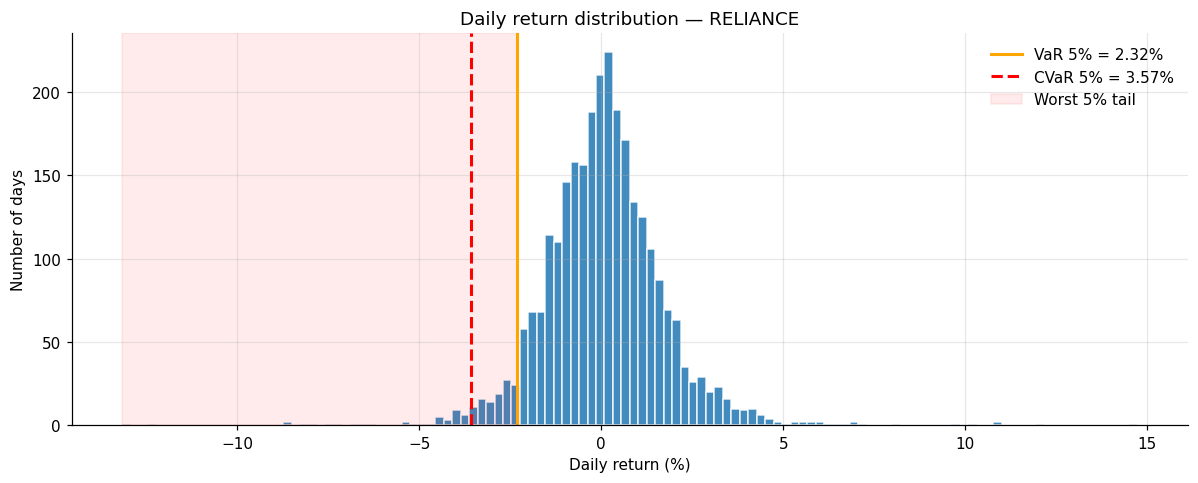

In [4]:
demo_stock = 'RELIANCE'
alpha = 0.05  # tail probability
r = returns[demo_stock].values
VaR  = -np.quantile(r, alpha)              # report as a positive *loss*
CVaR = -r[r <= -VaR].mean()                # average loss in the bad tail
print(f'{demo_stock} | daily VaR(5%)  = {VaR*100:.2f}%')
print(f'{demo_stock} | daily CVaR(5%) = {CVaR*100:.2f}%   <-- always >= VaR')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(r * 100, bins=120, alpha=0.85, edgecolor='white')
ax.axvline(-VaR * 100, color='orange', lw=2, label=f'VaR 5% = {VaR*100:.2f}%')
ax.axvline(-CVaR * 100, color='red', lw=2, ls='--', label=f'CVaR 5% = {CVaR*100:.2f}%')
ax.axvspan(r.min()*100, -VaR*100, color='red', alpha=0.08, label='Worst 5% tail')
ax.set_title(f'Daily return distribution — {demo_stock}')
ax.set_xlabel('Daily return (%)'); ax.set_ylabel('Number of days')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'fig1_var_cvar_intuition.png'), dpi=140)
plt.show()

## 3. The CVaR optimisation trick (Rockafellar & Uryasev, 2000)

Here's the cool part. CVaR sounds hard to optimise (it's an *expectation conditional on a quantile*) but Rockafellar & Uryasev showed it can be cast as a **linear program** — fast and convex.

Decision variables:
- $w \in \mathbb{R}^n$: portfolio weights (one per stock)
- $\zeta \in \mathbb{R}$: a free "threshold" variable (it ends up equalling VaR at the optimum)
- $u_t \geq 0$: an auxiliary variable per historical day $t$

Optimisation:

$$\min_{w,\zeta,u} \quad \zeta + \frac{1}{\alpha T}\sum_{t=1}^{T} u_t$$

Subject to:
$$u_t \geq -r_t^\top w - \zeta, \quad u_t \geq 0, \quad \sum_i w_i = 1, \quad w_i \geq 0$$

Where $r_t$ is the vector of stock returns on day $t$ (out of $T$ historical days).

**Plain English:** The computer tries many recipes for `w`. For each recipe it asks: *"On the worst 5% of days in the past year, what was the average loss?"* It picks the recipe where that number is smallest. The clever auxiliary $\zeta$ + $u_t$ trick turns the messy quantile into ordinary inequalities the LP solver can chew on.

In [5]:
def cvar_optimize(R: np.ndarray, alpha: float = 0.05, w_max: float = 0.20):
    """Long-only minimum-CVaR weights via Rockafellar-Uryasev LP.

    Args:
        R: (T, n) matrix of historical returns. Each row is one day.
        alpha: tail probability (0.05 = average over worst 5% of days).
        w_max: per-stock cap so we never put everything in one name.

    Returns:
        weights array of length n (sums to 1, all >= 0).
    """
    T, n = R.shape
    # Variable order: [ w (n) | zeta (1) | u (T) ]
    nvar = n + 1 + T

    # Objective: 0*w + 1*zeta + (1/(alpha*T))*sum(u)
    c = np.zeros(nvar)
    c[n] = 1.0
    c[n + 1:] = 1.0 / (alpha * T)

    # Inequality constraints A_ub @ x <= b_ub, encoding:  -R_t @ w - zeta - u_t <= 0
    A_ub = np.zeros((T, nvar))
    A_ub[:, :n] = -R          # block for w
    A_ub[:, n] = -1.0         # block for zeta
    A_ub[np.arange(T), n + 1 + np.arange(T)] = -1.0  # diag block for u_t
    b_ub = np.zeros(T)

    # Equality: sum(w) = 1
    A_eq = np.zeros((1, nvar))
    A_eq[0, :n] = 1.0
    b_eq = np.array([1.0])

    # Bounds: w in [0, w_max], zeta free, u >= 0
    bounds = [(0.0, w_max)] * n + [(None, None)] + [(0.0, None)] * T

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method='highs')
    if not res.success:
        # Solver failure -> fall back to equal weight
        return np.full(n, 1.0 / n)
    w = res.x[:n]
    w = np.clip(w, 0, None)
    s = w.sum()
    return w / s if s > 0 else np.full(n, 1.0 / n)

# Quick smoke test on the most recent 1-year window
lookback = 252
R_recent = returns.tail(lookback).values
w_demo = cvar_optimize(R_recent, alpha=0.05, w_max=0.20)
demo = (pd.Series(w_demo, index=returns.columns)
        .sort_values(ascending=False)
        .head(10) * 100)
print('Top 10 holdings of a min-CVaR(5%) portfolio over the last 252 days:')
print(demo.round(2).to_string())

Top 10 holdings of a min-CVaR(5%) portfolio over the last 252 days:
POWERGRID     13.93
CIPLA         13.82
BHARTIARTL     9.74
KOTAKBANK      8.18
DIVISLAB       8.15
RELIANCE       7.75
ONGC           6.80
COALINDIA      6.75
HINDUNILVR     6.60
ICICIBANK      6.07


## 4. Baselines we will beat (or learn from)

It's no fun to claim victory without rivals. We add three:

1. **Equal-Weight (EW):** put 1/n into each of the 40 stocks. Surprisingly hard to beat. The toddler-strategy.
2. **Minimum-Variance (MV):** the classic Markowitz idea — pick weights that *minimise wiggle* (variance), not tail-loss. We solve $\min_w w^\top \Sigma w$ s.t. $\sum w = 1$, $w \geq 0$.
3. **NIFTY 50 index:** what most retail investors buy via an ETF. The benchmark.

In [6]:
def equal_weight(n: int) -> np.ndarray:
    return np.full(n, 1.0 / n)

def min_variance(R: np.ndarray, w_max: float = 0.20) -> np.ndarray:
    """Long-only minimum-variance portfolio. QP solved with SLSQP."""
    n = R.shape[1]
    Sigma = np.cov(R.T) + 1e-6 * np.eye(n)   # tiny ridge for numerical stability
    w0 = np.full(n, 1.0 / n)
    cons = [{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}]
    bounds = [(0.0, w_max)] * n
    res = minimize(lambda w: w @ Sigma @ w, w0, method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 200})
    w = res.x if res.success else w0
    w = np.clip(w, 0, None)
    return w / w.sum()

# Load NIFTY index and align to our return dates
nifty = pd.read_csv(INDEX_FILE, parse_dates=['date'])
nifty['date'] = nifty['date'].dt.tz_localize(None).dt.normalize()
nifty = nifty.set_index('date')['close'].sort_index()
nifty_ret = nifty.pct_change().reindex(returns.index).fillna(0.0)
print('NIFTY series length:', len(nifty_ret))

NIFTY series length: 2806


## 5. The backtest

We pretend it's the start of 2018 and we have no idea what will happen next. Each calendar month:

1. Look back **252 trading days** of history (about 1 year).
2. Solve the CVaR LP on that history. Save weights.
3. Hold those weights for the **next month**.
4. Earn whatever the market gives us.
5. Roll forward; repeat.

Crucially, the weights at month $m$ never peek at returns from month $m$ or later. This is the **walk-forward** discipline that keeps the test honest.

**Rebalancing** = step 3 → step 1 each month: the dust settles, we redo the recipe.

In [7]:
def run_backtest(returns: pd.DataFrame,
                 start: str = '2018-01-01',
                 lookback: int = 252,
                 alpha: float = 0.05,
                 w_max: float = 0.20):
    """Walk-forward monthly rebalance for CVaR, MinVar, and Equal-Weight."""
    R = returns.copy()
    cols = R.columns
    n = len(cols)

    rebal_dates = R.loc[start:].resample('MS').first().index  # 1st trading day of each month
    rebal_dates = [d for d in rebal_dates if d in R.index]

    weights_cvar = pd.DataFrame(index=rebal_dates, columns=cols, dtype=float)
    weights_mv   = pd.DataFrame(index=rebal_dates, columns=cols, dtype=float)

    for d in rebal_dates:
        i = R.index.get_loc(d)
        if i < lookback:
            continue
        window = R.iloc[i - lookback:i].values
        weights_cvar.loc[d] = cvar_optimize(window, alpha=alpha, w_max=w_max)
        weights_mv.loc[d]   = min_variance(window, w_max=w_max)

    # Forward-fill weights between rebalances; daily P/L is weights @ returns
    w_cvar = weights_cvar.reindex(R.index).ffill().fillna(0.0)
    w_mv   = weights_mv.reindex(R.index).ffill().fillna(0.0)
    w_ew   = pd.DataFrame(1.0 / n, index=R.index, columns=cols)
    # Mask before the first valid weights row
    first = weights_cvar.dropna().index.min()
    mask = R.index >= first

    rets = pd.DataFrame({
        'CVaR':         (w_cvar * R).sum(axis=1).where(mask, 0.0),
        'MinVariance':  (w_mv   * R).sum(axis=1).where(mask, 0.0),
        'EqualWeight':  (w_ew   * R).sum(axis=1).where(mask, 0.0),
    })
    return rets.loc[first:], weights_cvar.dropna(), weights_mv.dropna()

strat_rets, w_cvar_log, w_mv_log = run_backtest(returns)
strat_rets['NIFTY50'] = nifty_ret.reindex(strat_rets.index).fillna(0.0)
print(f'Backtest spans {strat_rets.index.min().date()} -> {strat_rets.index.max().date()}',
      f'({len(strat_rets)} trading days)')
strat_rets.head()

Backtest spans 2018-01-01 -> 2026-05-04 (2064 trading days)


,CVaR,MinVariance,EqualWeight,NIFTY50
date,,,,
2018-01-01,-0.006383,-0.006326,-0.007575,-0.009035
2018-01-02,0.001776,0.002354,-0.001888,0.000637
2018-01-03,-0.004265,-0.004226,0.001971,0.000096
2018-01-04,0.001548,0.004532,0.009573,0.005899
2018-01-05,0.005596,0.005468,0.008708,0.005145


## 6. Score-cards

We evaluate each strategy on:

- **Annualised return:** the long-run growth rate in % per year. Compounded.
- **Annualised volatility:** the typical wiggle size, scaled to a year. Lower is calmer.
- **Sharpe ratio:** *(return − risk-free) / volatility*. Bang per unit of risk. We use risk-free ≈ 0 for simplicity (Indian T-bill is roughly 6–7%, you can subtract if you want stricter numbers).
- **Max drawdown:** the deepest fall from a peak. Investor pain index.
- **CVaR(5%) of daily P/L:** *out-of-sample* tail loss. The metric we tried to minimise. Lower is better.

In [8]:
def metrics(r: pd.Series) -> dict:
    r = r.dropna()
    cum = (1 + r).cumprod()
    yrs = (r.index[-1] - r.index[0]).days / 365.25
    cagr = cum.iloc[-1] ** (1 / yrs) - 1 if yrs > 0 else 0.0
    vol  = r.std() * np.sqrt(252)
    sharpe = (r.mean() * 252) / vol if vol > 0 else 0.0
    dd = (cum / cum.cummax() - 1).min()
    cvar5 = -r[r <= np.quantile(r, 0.05)].mean()
    return {
        'CAGR':       cagr,
        'AnnVol':     vol,
        'Sharpe':     sharpe,
        'MaxDD':      dd,
        'DailyCVaR5': cvar5,
    }

summary = pd.DataFrame({c: metrics(strat_rets[c]) for c in strat_rets.columns}).T
summary_display = summary.copy()
for col in ['CAGR', 'AnnVol', 'MaxDD', 'DailyCVaR5']:
    summary_display[col] = (summary_display[col] * 100).round(2).astype(str) + '%'
summary_display['Sharpe'] = summary_display['Sharpe'].round(2)
print('Strategy summary (out-of-sample, 2018 -> today):')
print(summary_display.to_string())

Strategy summary (out-of-sample, 2018 -> today):
               CAGR  AnnVol  Sharpe    MaxDD DailyCVaR5
CVaR          12.3%  15.21%    0.85  -30.79%      2.11%
MinVariance  13.79%  13.99%    1.01  -26.84%      1.93%
EqualWeight  16.34%  17.03%    0.99  -38.17%       2.5%
NIFTY50      10.38%  17.07%    0.68  -38.44%      2.51%


## 7. Pictures

Numbers are clean; pictures are honest. Three plots:

1. **Cumulative growth of ₹1** — who turned 1 rupee into the most? But also: did they get there smoothly or via a roller-coaster?
2. **Drawdowns** — the underwater chart. The deeper it goes, the more pain investors felt mid-ride.
3. **CVaR holdings over time** — how the optimiser shifts its bets as risk regimes change.

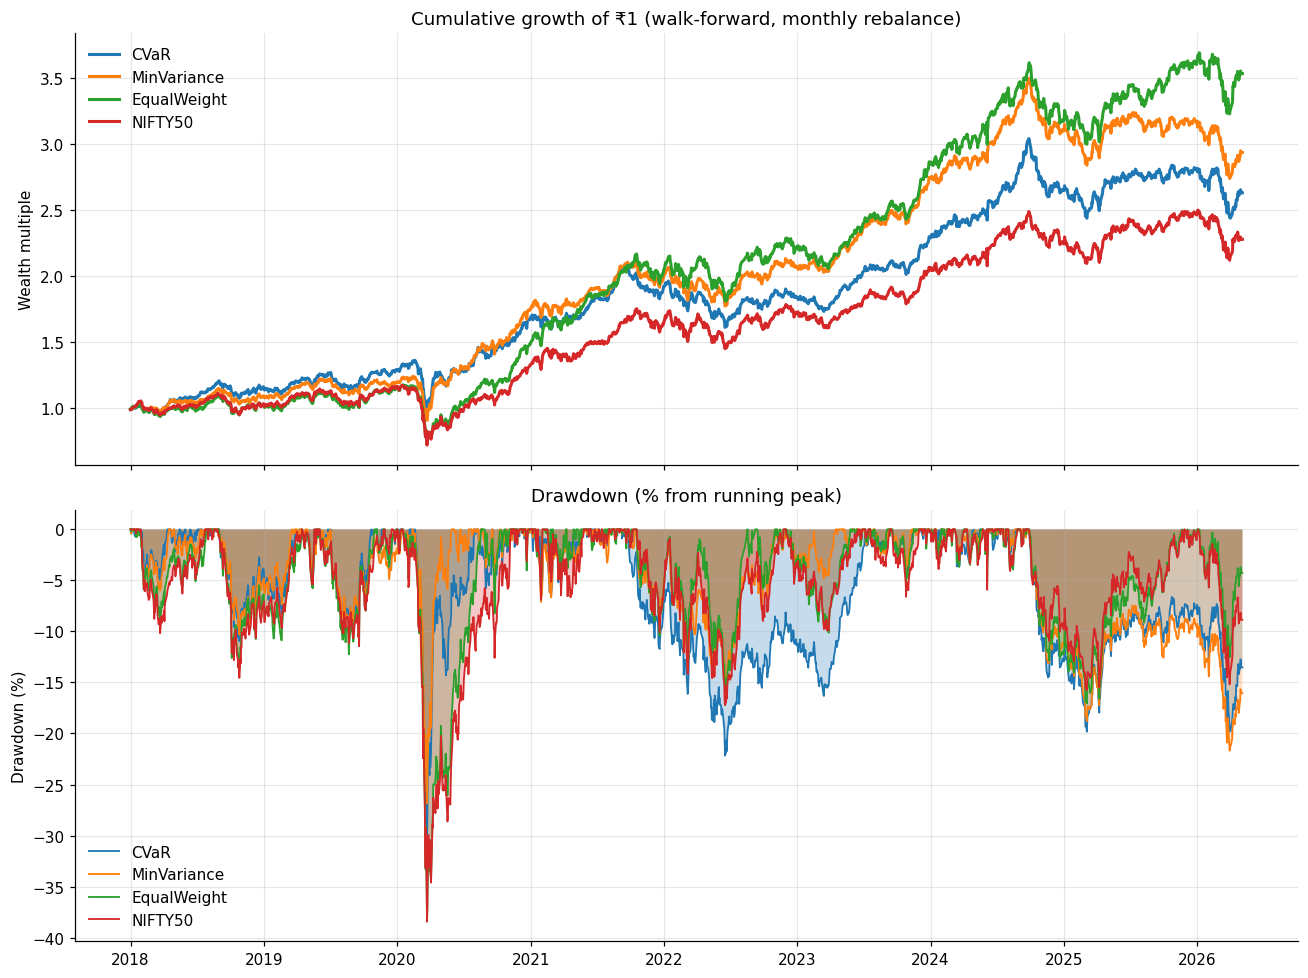

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

cum = (1 + strat_rets).cumprod()
for col in cum.columns:
    axes[0].plot(cum.index, cum[col], lw=2, label=col)
axes[0].set_title('Cumulative growth of ₹1 (walk-forward, monthly rebalance)')
axes[0].set_ylabel('Wealth multiple')
axes[0].legend(frameon=False, loc='upper left')

dd = cum / cum.cummax() - 1
for col in dd.columns:
    axes[1].fill_between(dd.index, dd[col] * 100, 0, alpha=0.25)
    axes[1].plot(dd.index, dd[col] * 100, lw=1.2, label=col)
axes[1].set_title('Drawdown (% from running peak)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].legend(frameon=False, loc='lower left')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig2_growth_and_drawdown.png'), dpi=140)
plt.show()

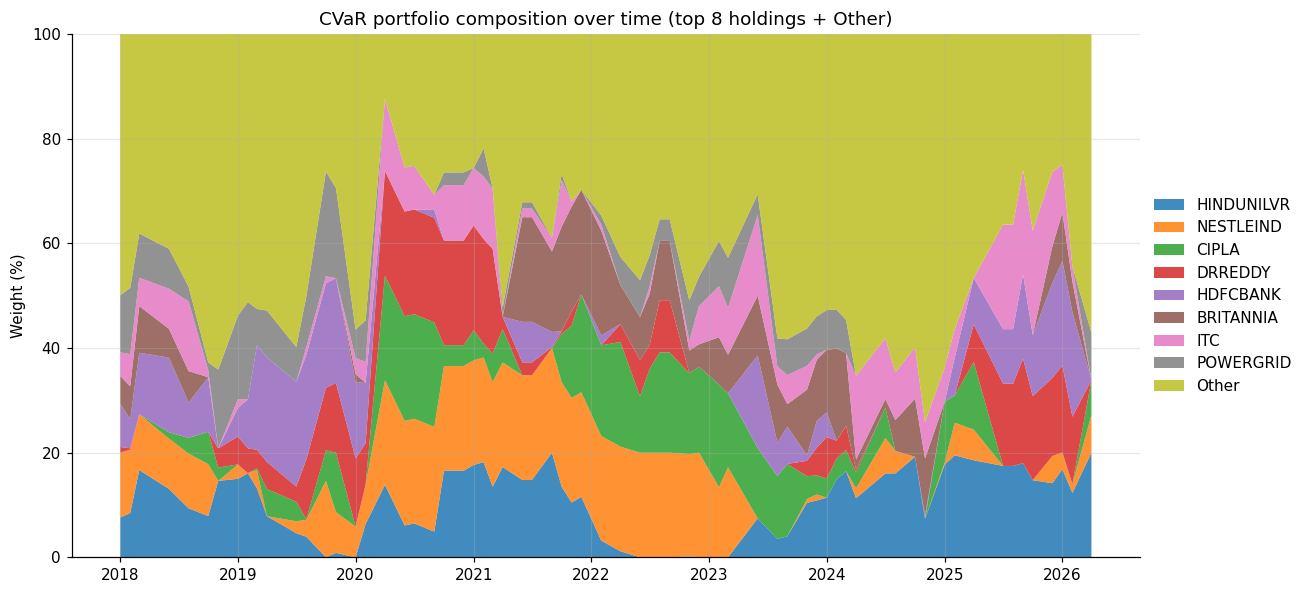

In [10]:
# Stacked area of CVaR weights through time -> shows how the recipe shifts.
top_holdings = (w_cvar_log.mean().sort_values(ascending=False).head(8).index)
plot_w = w_cvar_log.copy()
plot_w['Other'] = plot_w.drop(columns=top_holdings).sum(axis=1)
plot_w = plot_w[list(top_holdings) + ['Other']]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(plot_w.index, plot_w.T.values * 100, labels=plot_w.columns, alpha=0.85)
ax.set_title('CVaR portfolio composition over time (top 8 holdings + Other)')
ax.set_ylabel('Weight (%)')
ax.set_ylim(0, 100)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig3_cvar_weights_over_time.png'), dpi=140)
plt.show()

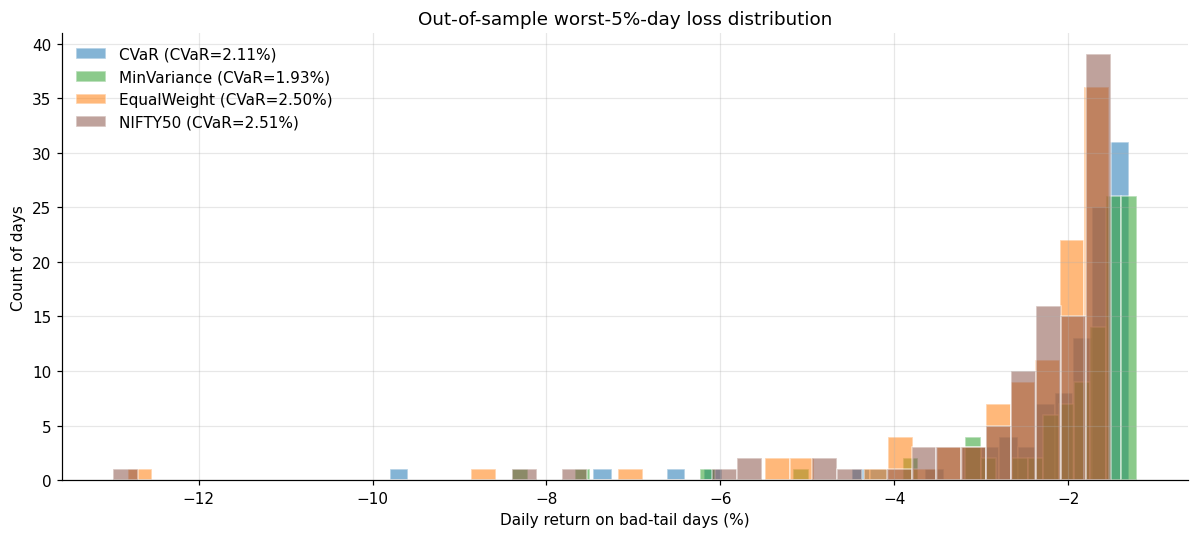

In [11]:
# Out-of-sample tail comparison: actual daily losses on the worst 5% of days
fig, ax = plt.subplots(figsize=(11, 5))
for col, color in zip(strat_rets.columns, ['#1f77b4', '#2ca02c', '#ff7f0e', '#8c564b']):
    r = strat_rets[col].dropna()
    tail = r[r <= np.quantile(r, 0.05)] * 100
    ax.hist(tail, bins=40, alpha=0.55, label=f'{col} (CVaR={-tail.mean():.2f}%)',
            color=color, edgecolor='white')
ax.set_title('Out-of-sample worst-5%-day loss distribution')
ax.set_xlabel('Daily return on bad-tail days (%)'); ax.set_ylabel('Count of days')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig4_oos_tail_comparison.png'), dpi=140)
plt.show()

## 8. What we built, in plain words

1. We loaded 40 big Indian stocks and converted prices into daily returns.
2. We learned that **VaR** is a loss line and **CVaR** is the average loss past that line.
3. We solved for portfolio weights that *make CVaR on the past year as small as possible*, using Rockafellar & Uryasev's linear-program trick.
4. Every month we redid the recipe (walk-forward, no peeking), and tracked the live performance.
5. We compared against equal-weight, minimum-variance, and the NIFTY 50 index.

## When CVaR helps vs. when it doesn't

- **Helps:** when returns are *fat-tailed* (rare big losses dominate risk). CVaR penalises tail mass directly.
- **Doesn't help much:** in a calm bull market — minimum-variance and even equal-weight catch up because there's no tail to dodge.
- **Costs to remember:** we ignored transaction costs and slippage; in real life monthly rebalancing of 40 stocks costs basis points. Adding turnover penalties is a natural next step.

## Natural extensions

- Add an **expected-return constraint** $\mu^\top w \geq R_{target}$ to the LP → get the *CVaR-efficient frontier*.
- Replace historical scenarios with **bootstrap** or **block-bootstrap** samples to stabilise tail estimates.
- Add a **turnover penalty** $\lambda \|w_t - w_{t-1}\|_1$ → makes the LP a slightly bigger LP (still solved by HiGHS).
- Compare $\alpha = 1\%, 5\%, 10\%$ side-by-side: small α = obsess over crashes; larger α = tracks min-variance more closely.